# 🔬 Test Swin2SR — Image Super-Resolution (x2)
**Model:** `caidas/swin2SR-classical-sr-x2-64`  
**Dataset:** `datasets/dataset_upscale/` (low_res + high_res pairs)
---

## 1. Setup

In [3]:
import torch, numpy as np, matplotlib.pyplot as plt, time, os, psutil, io
from PIL import Image, ImageFilter
from transformers import AutoImageProcessor, AutoModelForImageToImage
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB')

Device: cuda
GPU: NVIDIA GeForce GTX 1650 | VRAM: 4.0 GB


## 2. Încărcare Model

In [4]:
MODEL_ID = 'caidas/swin2SR-classical-sr-x2-64'
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageToImage.from_pretrained(MODEL_ID).to(device)
model.eval()
total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model: {MODEL_ID}')
print(f'   Parametri: {total_params:,}')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Model: caidas/swin2SR-classical-sr-x2-64
   Parametri: 12,091,571


## 3. Încărcare Dataset
Citește perechi LR/HR din `datasets/dataset_upscale/`.  
Setează `MAX_IMAGES` pt câte imagini să proceseze.

✅ 855 perechi LR/HR găsite
   LR dir: c:\Users\redis\Desktop\Projects\Licenta-App\test_modele_ai\datasets\dataset_upscale\low_res
   HR dir: c:\Users\redis\Desktop\Projects\Licenta-App\test_modele_ai\datasets\dataset_upscale\high_res


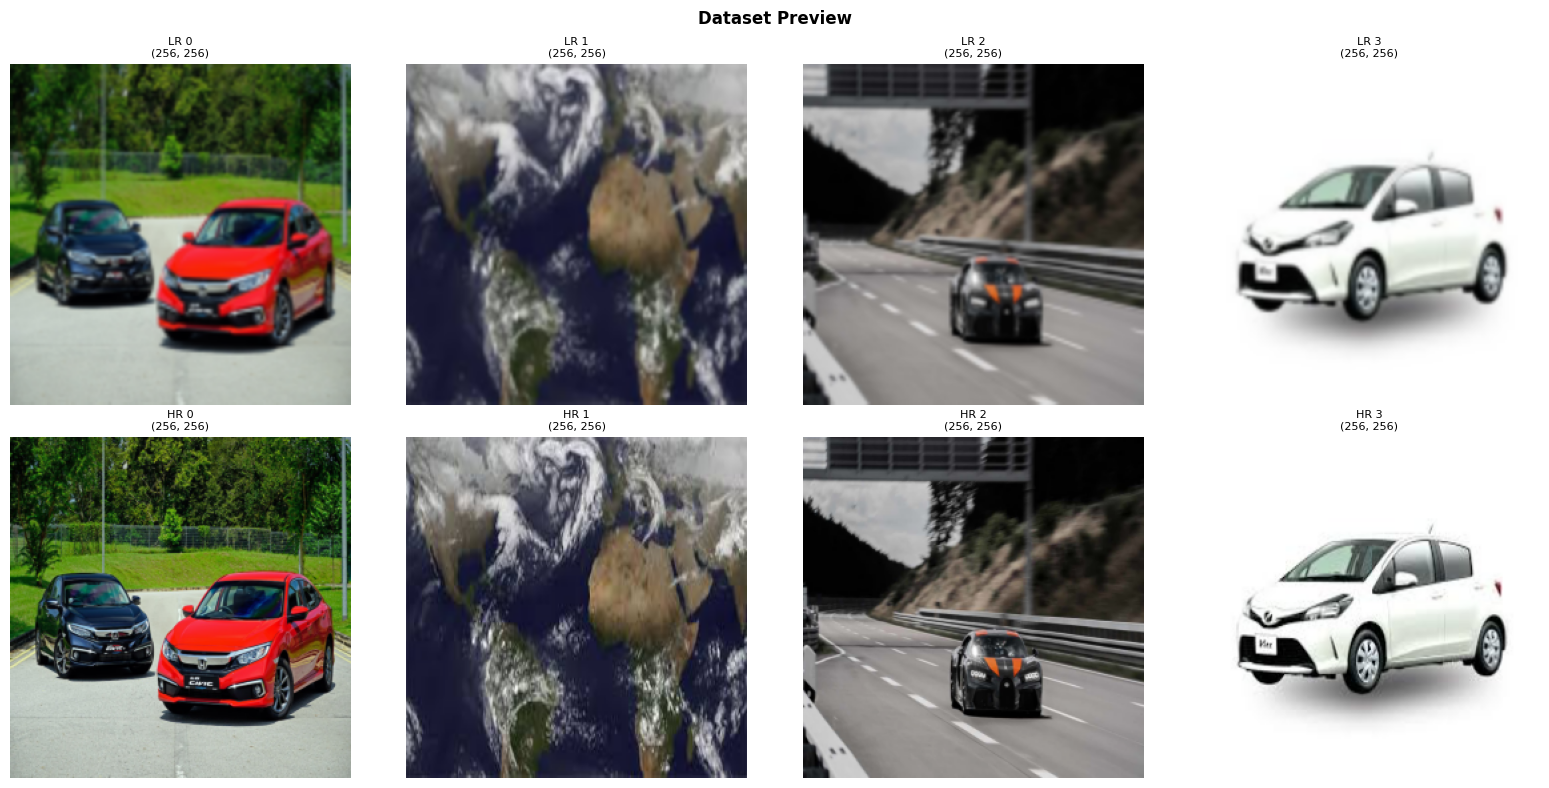

In [5]:
# ============================================================
# ⚙️ CONFIGURARE — Modifică MAX_IMAGES
# ============================================================
MAX_IMAGES = None  # câte imagini să proceseze (None = toate 855)

BASE = Path(os.path.dirname(os.path.abspath('__file__')))
LR_DIR = BASE / 'datasets' / 'dataset_upscale' / 'low_res'
HR_DIR = BASE / 'datasets' / 'dataset_upscale' / 'high_res'

# Găsește perechi LR/HR cu același nume
lr_files = sorted(LR_DIR.glob('*.png'), key=lambda f: int(f.stem))
hr_files = {f.stem: f for f in HR_DIR.glob('*.png')}

pairs = []
for lr_f in lr_files:
    if lr_f.stem in hr_files:
        pairs.append((lr_f, hr_files[lr_f.stem]))

if MAX_IMAGES:
    pairs = pairs[:MAX_IMAGES]

print(f'✅ {len(pairs)} perechi LR/HR găsite')
print(f'   LR dir: {LR_DIR}')
print(f'   HR dir: {HR_DIR}')

# Preview primele 4
fig, axes = plt.subplots(2, min(4, len(pairs)), figsize=(16, 8))
for i in range(min(4, len(pairs))):
    lr = Image.open(pairs[i][0]).convert('RGB')
    hr = Image.open(pairs[i][1]).convert('RGB')
    axes[0,i].imshow(lr); axes[0,i].set_title(f'LR {pairs[i][0].stem}\n{lr.size}', fontsize=8); axes[0,i].axis('off')
    axes[1,i].imshow(hr); axes[1,i].set_title(f'HR {pairs[i][1].stem}\n{hr.size}', fontsize=8); axes[1,i].axis('off')
axes[0,0].set_ylabel('Low Res', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('High Res', fontsize=11, fontweight='bold')
plt.suptitle('Dataset Preview', fontweight='bold'); plt.tight_layout(); plt.show()

## 4. Funcții Metrici

In [6]:
def to_f64(img): return np.array(img).astype(np.float64)
def calc_psnr(a,b): return peak_signal_noise_ratio(to_f64(a), to_f64(b), data_range=255)
def calc_ssim(a,b): return structural_similarity(to_f64(a), to_f64(b), data_range=255, channel_axis=-1)
def calc_mse(a,b): return mean_squared_error(to_f64(a), to_f64(b))
def calc_rmse(a,b): return np.sqrt(calc_mse(a,b))
def calc_mae(a,b): return np.mean(np.abs(to_f64(a)-to_f64(b)))
def calc_sharpness(img):
    g = img.convert('L')
    lap = g.filter(ImageFilter.Kernel((3,3),[0,1,0,1,-4,1,0,1,0],1,128))
    return np.var(np.array(lap).astype(np.float64)-128.0)
def calc_entropy(img):
    h,_=np.histogram(np.array(img.convert('L')).flatten(),bins=256,range=(0,255),density=True)
    h=h[h>0]; return -np.sum(h*np.log2(h))
def calc_contrast(img): return np.std(np.array(img.convert('L')).astype(np.float64))
def calc_edge_density(img):
    e=np.array(img.convert('L').filter(ImageFilter.FIND_EDGES))
    return np.sum(e>30)/e.size*100
def calc_delta_e(a,b):
    from skimage.color import rgb2lab
    la=rgb2lab(to_f64(a)/255.0); lb=rgb2lab(to_f64(b)/255.0)
    return np.mean(np.sqrt(np.sum((la-lb)**2,axis=-1)))
def file_size(img,fmt='PNG'):
    buf=io.BytesIO(); img.save(buf,format=fmt); return buf.tell()
print('✅ Metrici definite')

✅ Metrici definite


## 5. Procesare — Swin2SR + Bicubic pe tot datasetul

In [7]:
results = []
for idx, (lr_path, hr_path) in enumerate(pairs):
    lr_img = Image.open(lr_path).convert('RGB')
    hr_img = Image.open(hr_path).convert('RGB')
    
    # Swin2SR inference
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    inputs = processor(lr_img, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    output = outputs.reconstruction.squeeze().cpu().clamp(0,1).numpy()
    sr_img = Image.fromarray((output.transpose(1,2,0)*255).astype(np.uint8))
    t_sr = time.perf_counter()-t0
    gpu_peak = torch.cuda.max_memory_allocated()/(1024**2) if torch.cuda.is_available() else 0
    
    # Resize SR și Bicubic la HR size pt comparare
    hr_w, hr_h = hr_img.size
    sr_img = sr_img.resize((hr_w, hr_h), Image.LANCZOS)
    bicubic_img = lr_img.resize((hr_w, hr_h), Image.BICUBIC)
    
    # Full-reference metrici (vs HR ground truth)
    r = {'idx': idx, 'name': lr_path.stem}
    for label, img in [('SR', sr_img), ('Bicubic', bicubic_img)]:
        r[f'{label}_PSNR'] = calc_psnr(hr_img, img)
        r[f'{label}_SSIM'] = calc_ssim(hr_img, img)
        r[f'{label}_MSE'] = calc_mse(hr_img, img)
        r[f'{label}_RMSE'] = calc_rmse(hr_img, img)
        r[f'{label}_MAE'] = calc_mae(hr_img, img)
        r[f'{label}_DeltaE'] = calc_delta_e(hr_img, img)
    
    # No-reference
    for label, img in [('LR', lr_img), ('SR', sr_img), ('Bicubic', bicubic_img), ('HR', hr_img)]:
        r[f'{label}_Sharp'] = calc_sharpness(img)
        r[f'{label}_Entropy'] = calc_entropy(img)
        r[f'{label}_Contrast'] = calc_contrast(img)
        r[f'{label}_Edge'] = calc_edge_density(img)
    
    r['time_s'] = t_sr
    r['gpu_peak_mb'] = gpu_peak
    r['throughput_mpx'] = (hr_w*hr_h)/(t_sr*1e6)
    r['lr_img'] = lr_img; r['sr_img'] = sr_img; r['bicubic_img'] = bicubic_img; r['hr_img'] = hr_img
    results.append(r)
    
    if (idx+1) % 5 == 0 or idx == 0:
        print(f'  [{idx+1}/{len(pairs)}] {lr_path.stem}: PSNR SR={r["SR_PSNR"]:.2f} vs Bic={r["Bicubic_PSNR"]:.2f} | {t_sr:.2f}s')

print(f'\n✅ {len(results)} imagini procesate!')

  [1/855] 0: PSNR SR=14.88 vs Bic=25.14 | 3.14s
  [5/855] 4: PSNR SR=16.34 vs Bic=25.61 | 2.39s
  [10/855] 9: PSNR SR=18.41 vs Bic=31.49 | 2.39s
  [15/855] 14: PSNR SR=25.44 vs Bic=37.57 | 2.39s
  [20/855] 19: PSNR SR=20.19 vs Bic=28.97 | 2.39s
  [25/855] 24: PSNR SR=17.52 vs Bic=24.72 | 2.40s
  [30/855] 29: PSNR SR=20.29 vs Bic=30.10 | 2.39s
  [35/855] 34: PSNR SR=16.93 vs Bic=27.79 | 2.39s
  [40/855] 39: PSNR SR=17.86 vs Bic=31.39 | 2.39s
  [45/855] 44: PSNR SR=20.14 vs Bic=31.45 | 2.39s
  [50/855] 49: PSNR SR=15.80 vs Bic=28.32 | 2.39s
  [55/855] 54: PSNR SR=16.05 vs Bic=28.98 | 2.40s
  [60/855] 59: PSNR SR=19.90 vs Bic=30.50 | 2.40s
  [65/855] 64: PSNR SR=17.67 vs Bic=28.07 | 2.39s
  [70/855] 69: PSNR SR=18.59 vs Bic=31.14 | 2.40s
  [75/855] 74: PSNR SR=16.17 vs Bic=24.74 | 2.39s
  [80/855] 79: PSNR SR=19.54 vs Bic=31.29 | 2.39s
  [85/855] 84: PSNR SR=18.04 vs Bic=27.99 | 2.39s
  [90/855] 89: PSNR SR=14.60 vs Bic=24.25 | 2.39s
  [95/855] 94: PSNR SR=19.39 vs Bic=27.36 | 2.39s
  [10

## 6. Comparație Vizuală (primele 4)

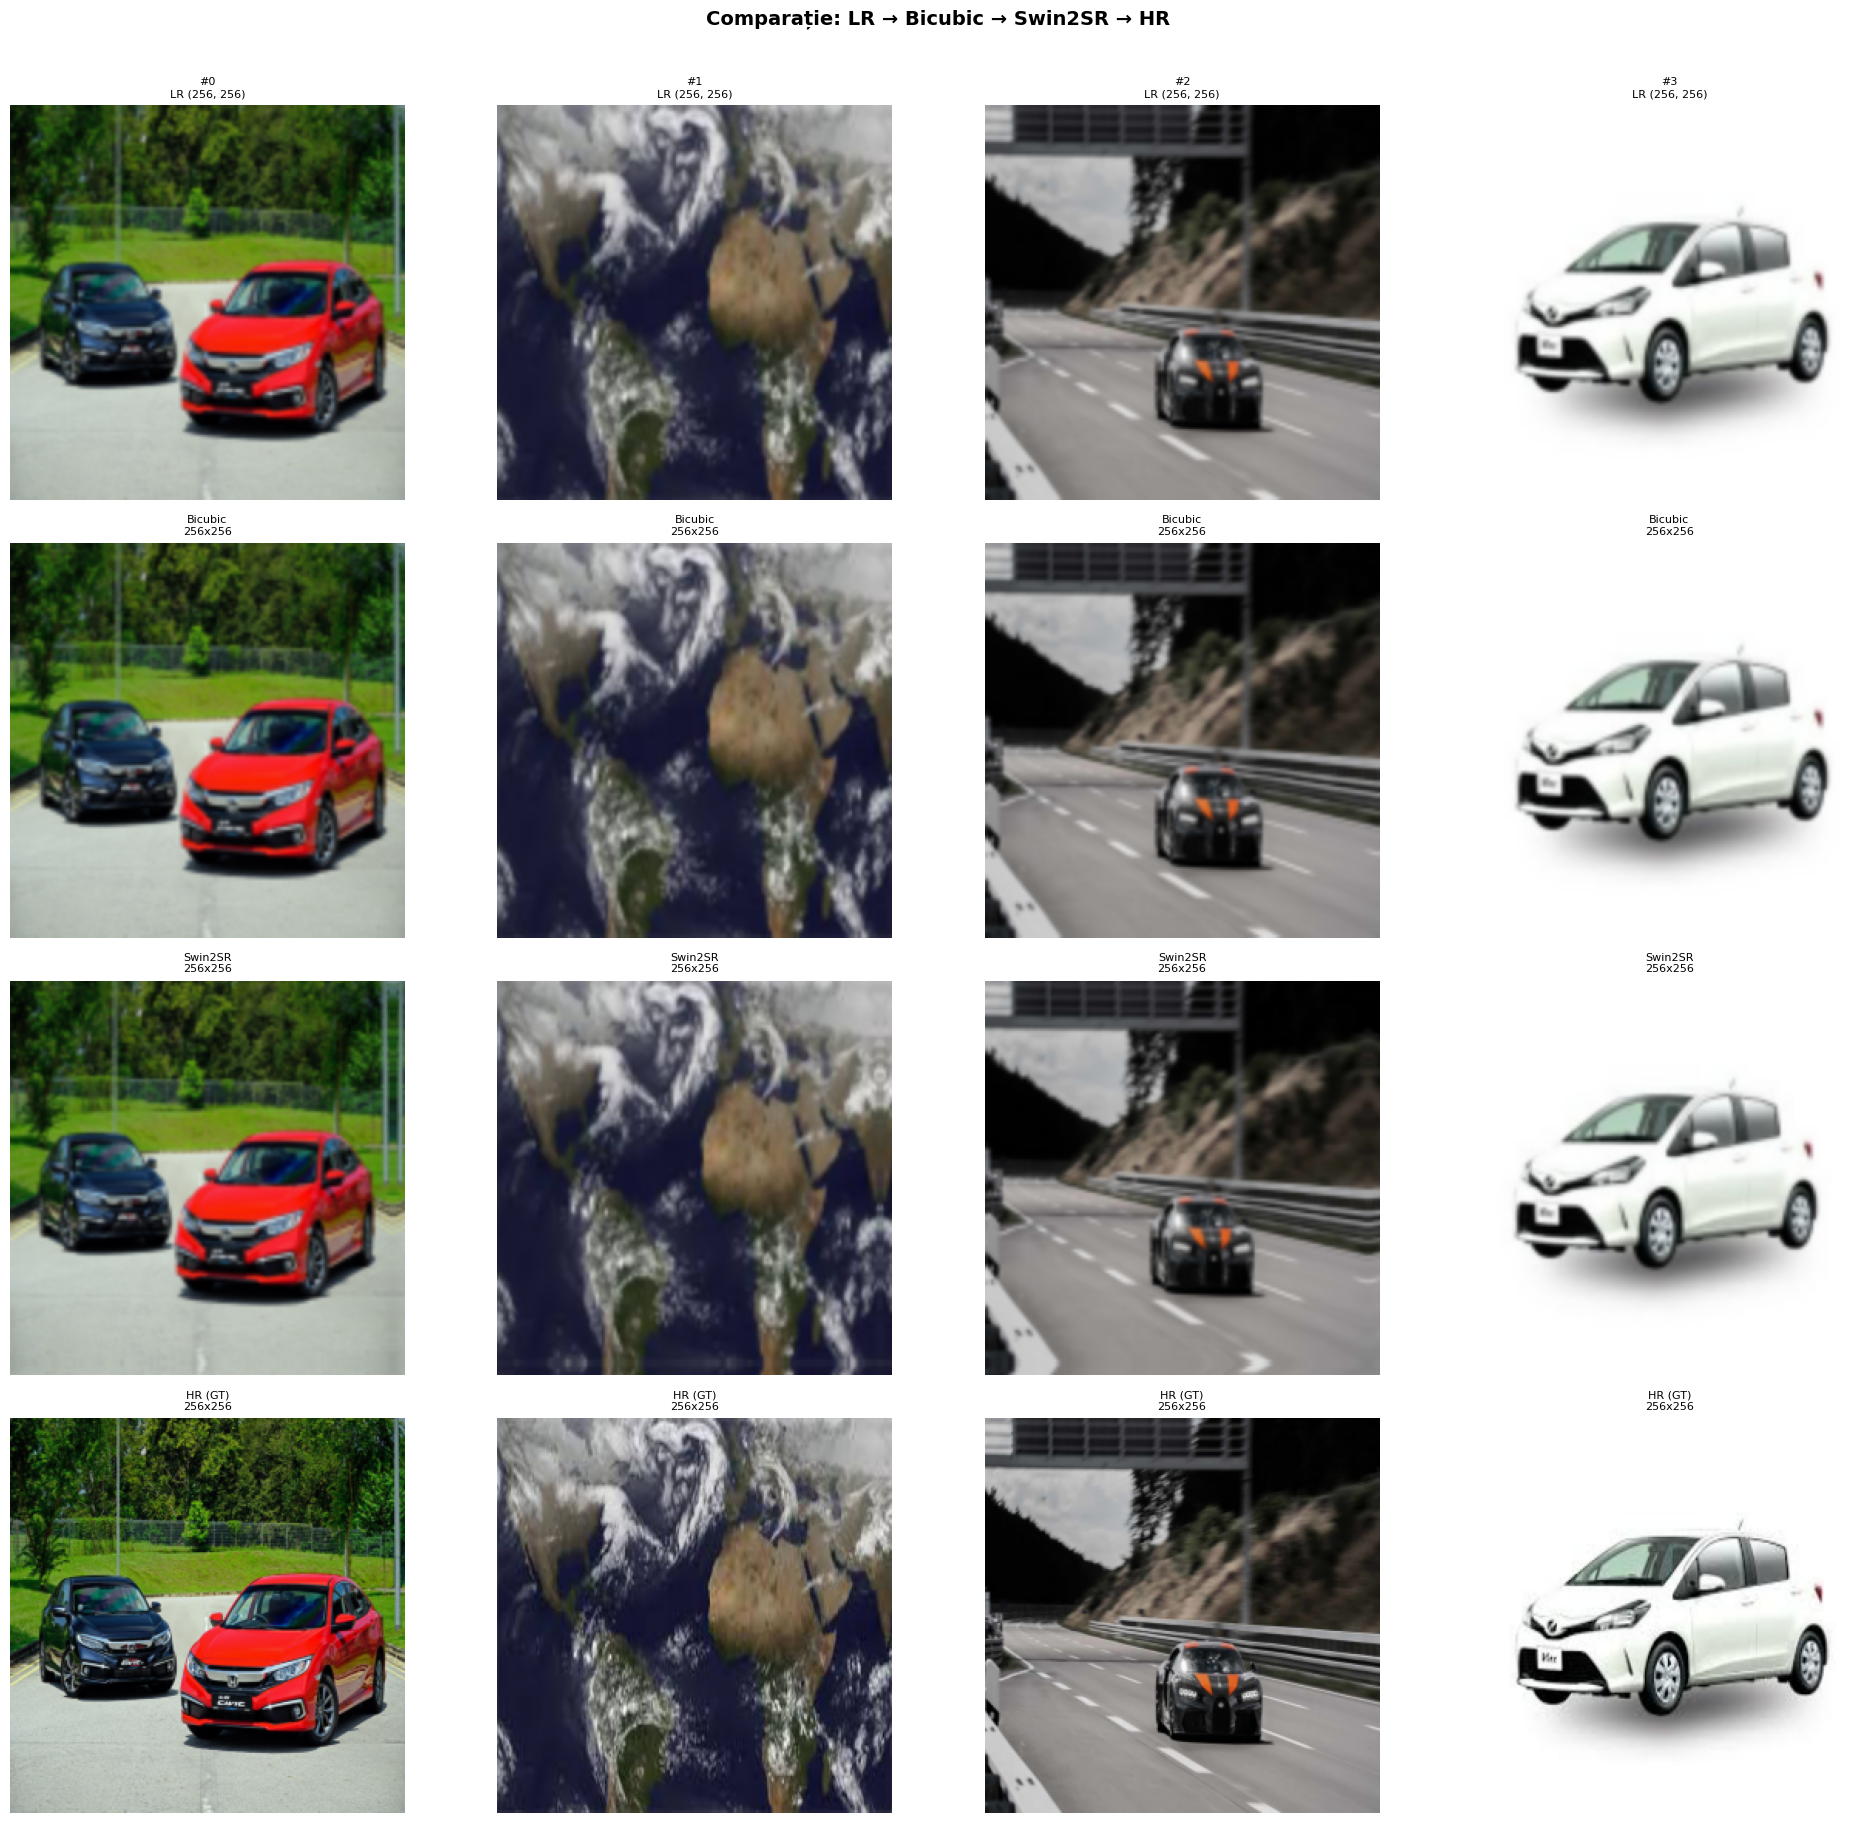

In [8]:
n_show = min(4, len(results))
fig, axes = plt.subplots(4, n_show, figsize=(5*n_show, 18))
for i in range(n_show):
    r = results[i]
    for row, (label, img) in enumerate([('LR', r['lr_img']), ('Bicubic', r['bicubic_img']), ('Swin2SR', r['sr_img']), ('HR (GT)', r['hr_img'])]):
        axes[row,i].imshow(img); axes[row,i].axis('off')
        axes[row,i].set_title(f'{label}\n{img.size[0]}x{img.size[1]}', fontsize=8)
    axes[0,i].set_title(f'#{r["name"]}\nLR {r["lr_img"].size}', fontsize=8)
for row, l in enumerate(['LR', 'Bicubic', 'Swin2SR', 'HR (GT)']):
    axes[row,0].set_ylabel(l, fontsize=11, fontweight='bold', rotation=90, labelpad=15)
plt.suptitle('Comparație: LR → Bicubic → Swin2SR → HR', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 7. Tabel Full-Reference (medie pe toate imaginile)

In [9]:
print('='*90)
print(f'METRICI FULL-REFERENCE — Medie pe {len(results)} imagini')
print('='*90)
metrics = ['PSNR', 'SSIM', 'MSE', 'RMSE', 'MAE', 'DeltaE']
print(f'{"Metrică":<12} {"Swin2SR":>12} {"Bicubic":>12} {"Câștigător":>14}')
print(f'{"─"*52}')
for m in metrics:
    sr_vals = [r[f'SR_{m}'] for r in results]
    bic_vals = [r[f'Bicubic_{m}'] for r in results]
    sr_mean, bic_mean = np.mean(sr_vals), np.mean(bic_vals)
    # Higher is better for PSNR, SSIM; lower for rest
    if m in ('PSNR', 'SSIM'):
        winner = '🟢 Swin2SR' if sr_mean > bic_mean else '🔵 Bicubic'
    else:
        winner = '🟢 Swin2SR' if sr_mean < bic_mean else '🔵 Bicubic'
    print(f'{m:<12} {sr_mean:>12.4f} {bic_mean:>12.4f} {winner:>14}')

METRICI FULL-REFERENCE — Medie pe 855 imagini
Metrică           Swin2SR      Bicubic     Câștigător
────────────────────────────────────────────────────
PSNR              18.0577      28.7354      🔵 Bicubic
SSIM               0.4516       0.8804      🔵 Bicubic
MSE             1261.9653     112.4738      🔵 Bicubic
RMSE              33.8307       9.9989      🔵 Bicubic
MAE               19.6841       5.6455      🔵 Bicubic
DeltaE            10.1520       2.7795      🔵 Bicubic


## 8. Grafice Full-Reference

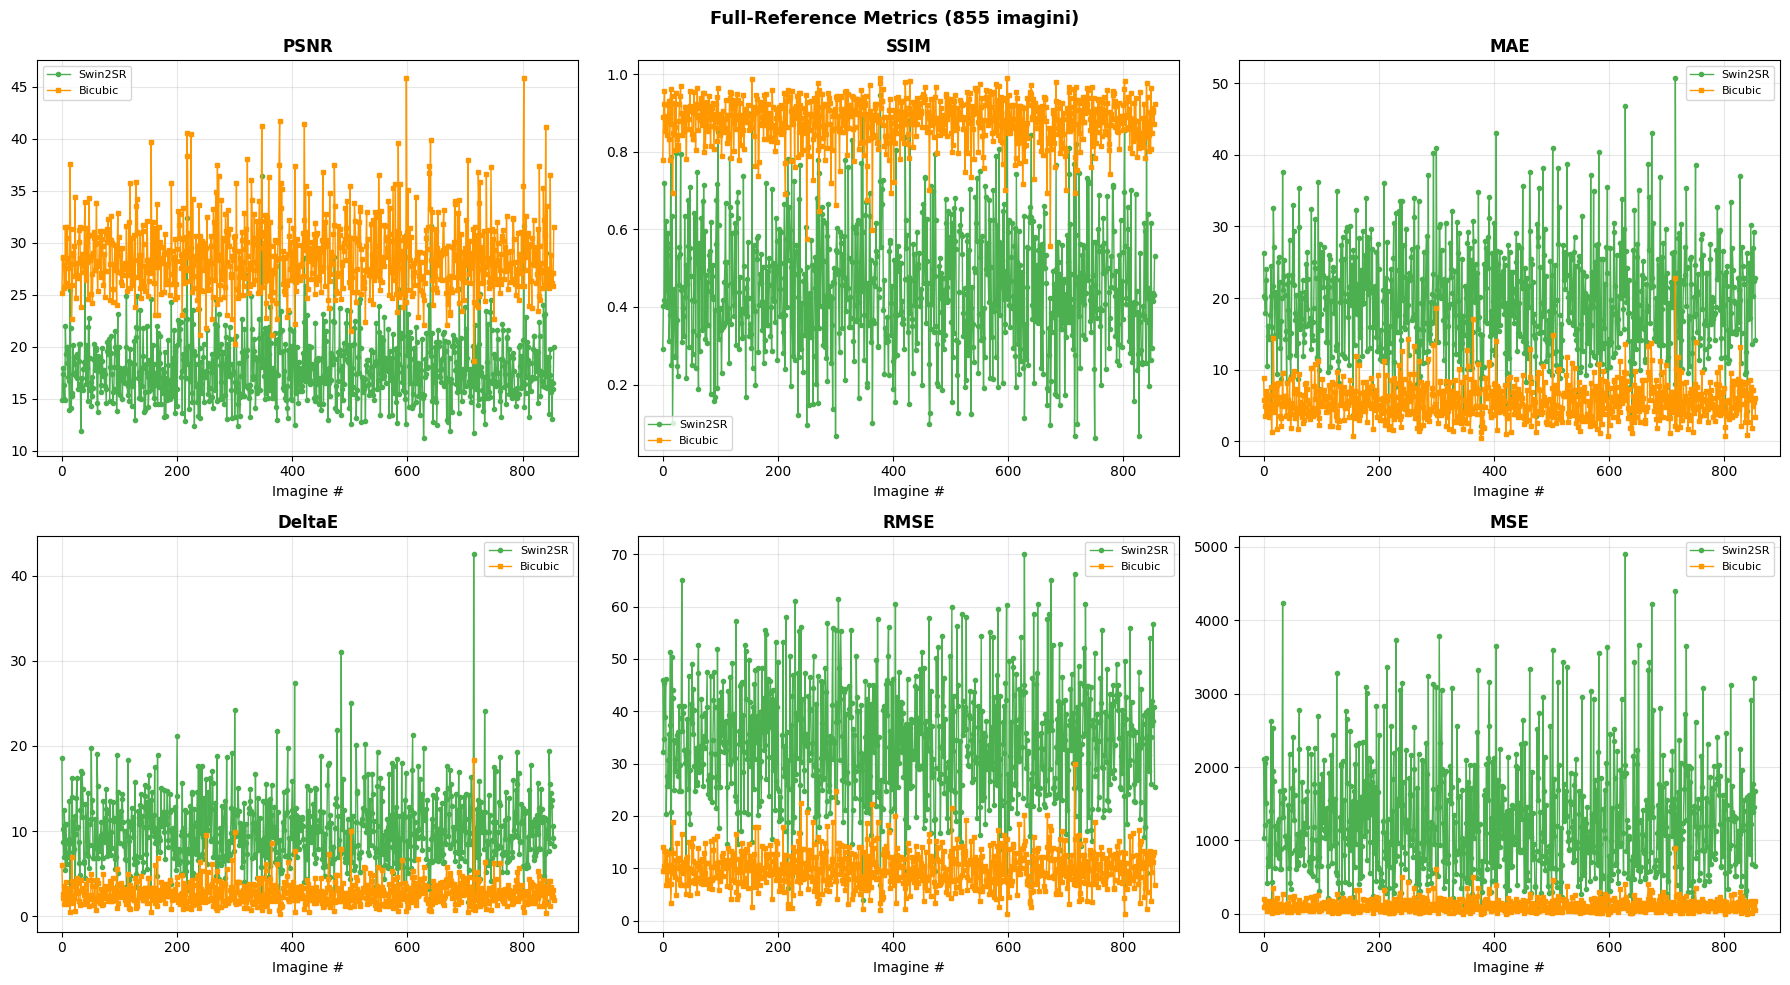

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, m in zip(axes.flat, ['PSNR', 'SSIM', 'MAE', 'DeltaE', 'RMSE', 'MSE']):
    sr_v = [r[f'SR_{m}'] for r in results]
    bic_v = [r[f'Bicubic_{m}'] for r in results]
    x = range(len(results))
    ax.plot(x, sr_v, 'o-', markersize=3, label='Swin2SR', color='#4CAF50', linewidth=1)
    ax.plot(x, bic_v, 's-', markersize=3, label='Bicubic', color='#FF9800', linewidth=1)
    ax.set_title(m, fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('Imagine #')
plt.suptitle(f'Full-Reference Metrics ({len(results)} imagini)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. No-Reference Metrics

In [11]:
print('='*90)
print(f'METRICI NO-REFERENCE — Medie pe {len(results)} imagini')
print('='*90)
for m in ['Sharp', 'Entropy', 'Contrast', 'Edge']:
    print(f'\n  {m}')
    print(f'  {"":15} {"LR":>10} {"Bicubic":>10} {"Swin2SR":>10} {"HR (GT)":>10}')
    print(f'  {"─"*57}')
    lr_v = np.mean([r[f'LR_{m}'] for r in results])
    bic_v = np.mean([r[f'Bicubic_{m}'] for r in results])
    sr_v = np.mean([r[f'SR_{m}'] for r in results])
    hr_v = np.mean([r[f'HR_{m}'] for r in results])
    print(f'  {"Medie":<15} {lr_v:>10.3f} {bic_v:>10.3f} {sr_v:>10.3f} {hr_v:>10.3f}')

METRICI NO-REFERENCE — Medie pe 855 imagini

  Sharp
                          LR    Bicubic    Swin2SR    HR (GT)
  ─────────────────────────────────────────────────────────
  Medie              162.137    162.137    173.644    950.434

  Entropy
                          LR    Bicubic    Swin2SR    HR (GT)
  ─────────────────────────────────────────────────────────
  Medie                7.028      7.028      7.014      7.057

  Contrast
                          LR    Bicubic    Swin2SR    HR (GT)
  ─────────────────────────────────────────────────────────
  Medie               52.814     52.814     52.740     55.396

  Edge
                          LR    Bicubic    Swin2SR    HR (GT)
  ─────────────────────────────────────────────────────────
  Medie                8.097      8.097      8.171     18.262


## 10. No-Reference Bar Charts

KeyError: 'Swin2SR_Sharp_Sharp'

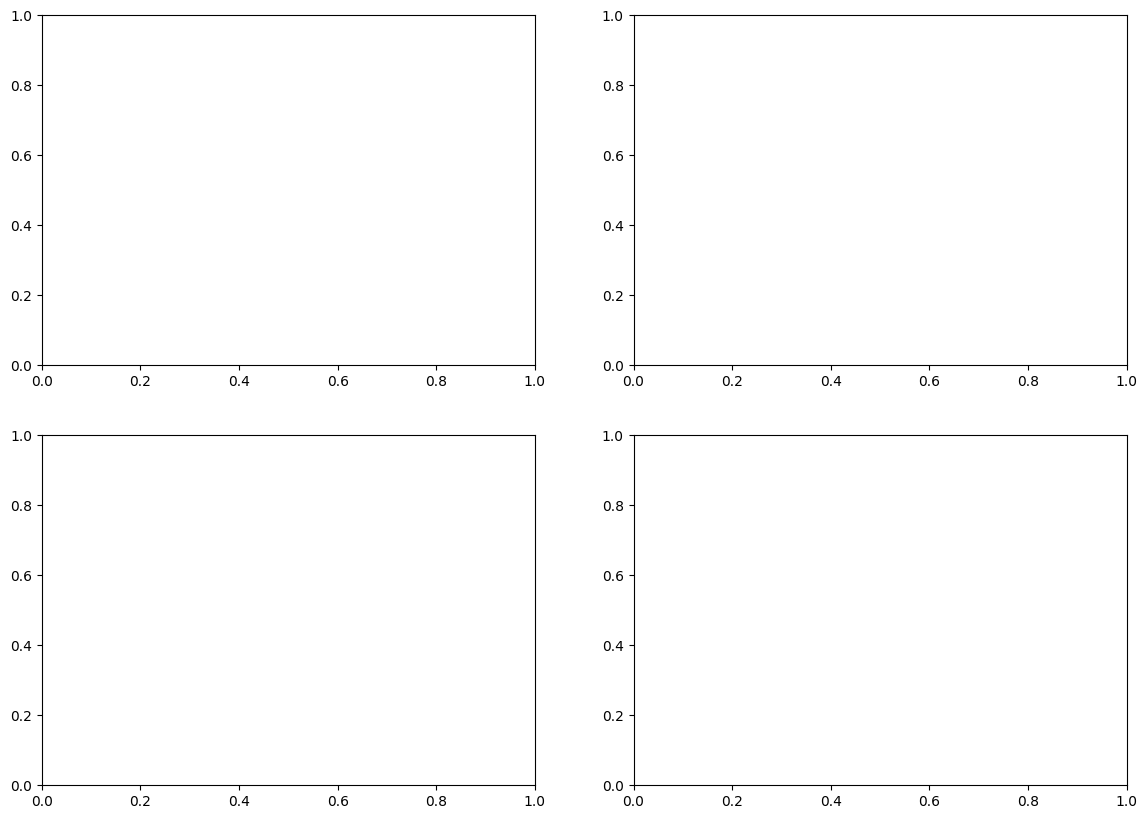

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, m in zip(axes.flat, ['Sharp', 'Entropy', 'Contrast', 'Edge']):
    labels = ['LR', 'Bicubic', 'Swin2SR', 'HR']
    vals = [np.mean([r[f'{l}_{m}'] for r in results]) for l in labels]
    colors = ['#9E9E9E', '#FF9800', '#4CAF50', '#2196F3']
    ax.bar(labels, vals, color=colors)
    ax.set_title(m, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
plt.suptitle(f'No-Reference Metrics — Medii ({len(results)} imagini)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Histograme Per Canal (primele 2)

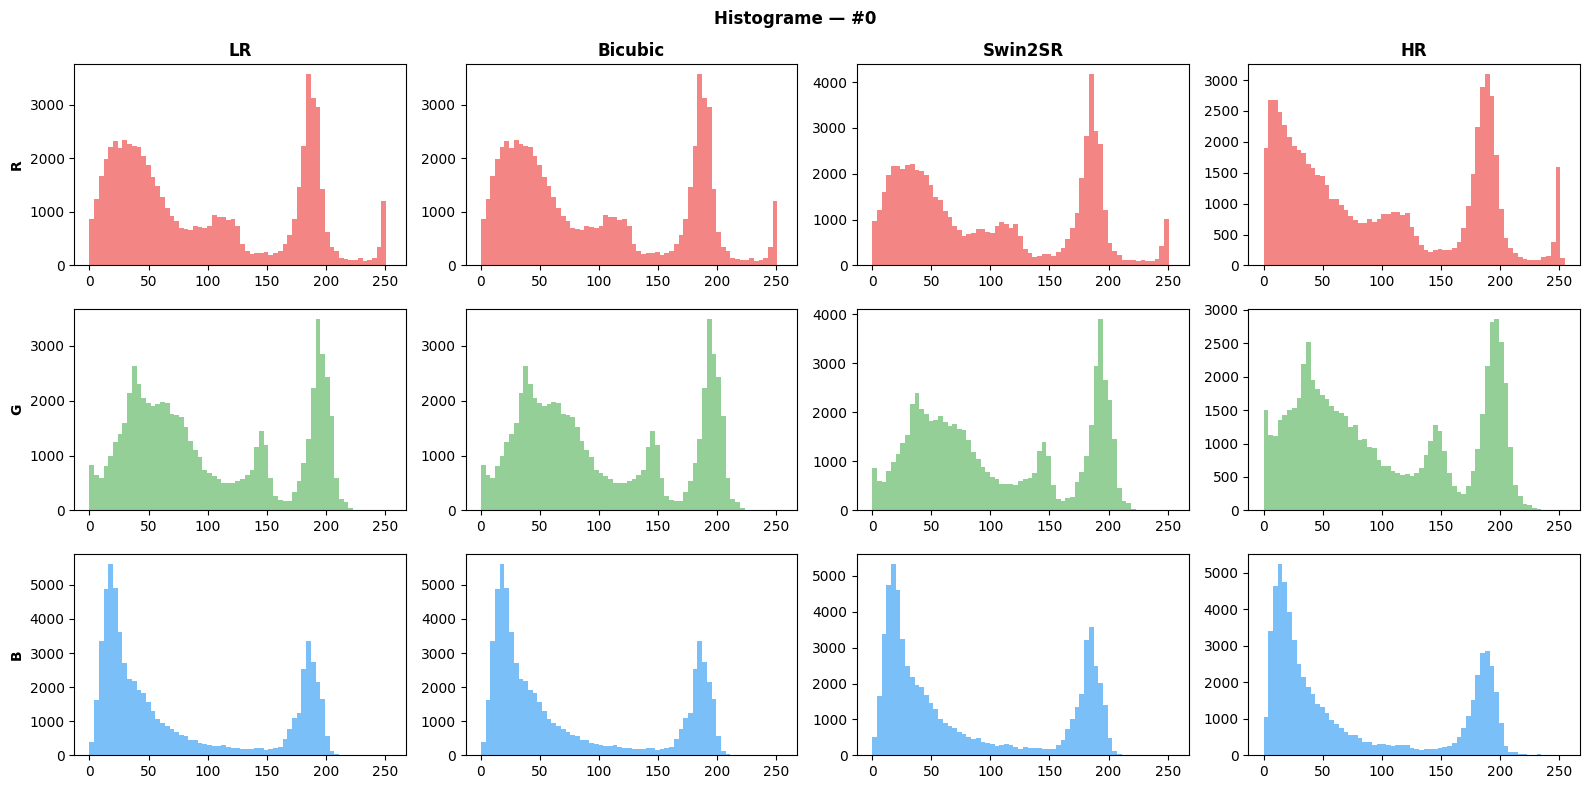

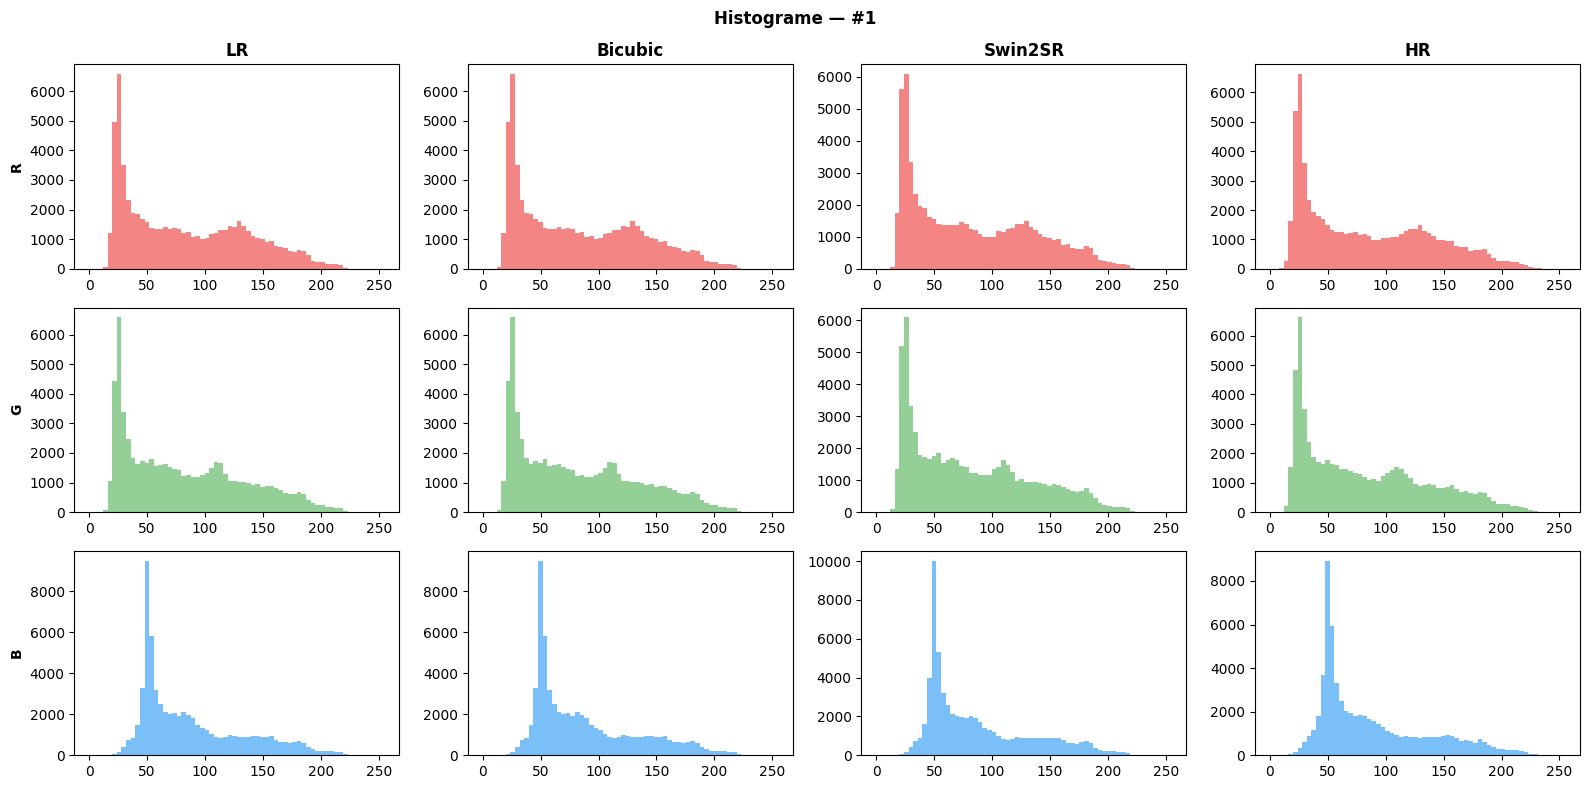

In [15]:
ch_colors = ['#EF5350','#66BB6A','#42A5F5']
for r in results[:2]:
    fig, axes = plt.subplots(3, 4, figsize=(16, 8))
    fig.suptitle(f'Histograme — #{r["name"]}', fontsize=12, fontweight='bold')
    for col, (label, img) in enumerate([('LR',r['lr_img']),('Bicubic',r['bicubic_img']),('Swin2SR',r['sr_img']),('HR',r['hr_img'])]):
        arr = np.array(img)
        for ch in range(3):
            axes[ch,col].hist(arr[:,:,ch].flatten(), bins=64, range=(0,255), color=ch_colors[ch], alpha=0.7)
            if ch==0: axes[ch,col].set_title(label, fontweight='bold')
            if col==0: axes[ch,col].set_ylabel(['R','G','B'][ch], fontweight='bold')
    plt.tight_layout(); plt.show()

## 12. Performanță

In [16]:
times = [r['time_s'] for r in results]
print('='*80)
print(f'PERFORMANȚĂ — {len(results)} imagini')
print('='*80)
print(f'  Timp total:     {sum(times):.1f}s')
print(f'  Timp mediu:     {np.mean(times):.3f}s / imagine')
print(f'  Timp median:    {np.median(times):.3f}s / imagine')
print(f'  Min/Max:        {min(times):.3f}s / {max(times):.3f}s')
print(f'  GPU peak mediu: {np.mean([r["gpu_peak_mb"] for r in results]):.0f} MB')
print(f'  Throughput:     {np.mean([r["throughput_mpx"] for r in results]):.3f} Mpx/s')

PERFORMANȚĂ — 855 imagini
  Timp total:     2047.1s
  Timp mediu:     2.394s / imagine
  Timp median:    2.393s / imagine
  Min/Max:        2.387s / 3.144s
  GPU peak mediu: 857 MB
  Throughput:     0.027 Mpx/s


## 13. Sumar Final

In [17]:
print('█'*70)
print(f'  SUMAR — Swin2SR ({len(results)} imagini)')
print('█'*70)
print(f'  Model:     {MODEL_ID}')
print(f'  Parametri: {total_params:,}')
print(f'  Device:    {device}')
print(f'  Imagini:   {len(results)}')
print(f'')
print(f'  {"Metrică":<15} {"Swin2SR":>10} {"Bicubic":>10} {"Winner":>10}')
print(f'  {"─"*47}')
for m in ['PSNR','SSIM','MAE','DeltaE','RMSE']:
    sr = np.mean([r[f'SR_{m}'] for r in results])
    bic = np.mean([r[f'Bicubic_{m}'] for r in results])
    w = 'SR' if (sr>bic if m in ('PSNR','SSIM') else sr<bic) else 'Bic'
    print(f'  {m:<15} {sr:>10.4f} {bic:>10.4f} {w:>10}')
print(f'\n  Timp mediu: {np.mean(times):.3f}s/img')
print('█'*70)

██████████████████████████████████████████████████████████████████████
  SUMAR — Swin2SR (855 imagini)
██████████████████████████████████████████████████████████████████████
  Model:     caidas/swin2SR-classical-sr-x2-64
  Parametri: 12,091,571
  Device:    cuda
  Imagini:   855

  Metrică            Swin2SR    Bicubic     Winner
  ───────────────────────────────────────────────
  PSNR               18.0577    28.7354        Bic
  SSIM                0.4516     0.8804        Bic
  MAE                19.6841     5.6455        Bic
  DeltaE             10.1520     2.7795        Bic
  RMSE               33.8307     9.9989        Bic

  Timp mediu: 2.394s/img
██████████████████████████████████████████████████████████████████████


## 14. Salvare

In [ ]:
OUT = BASE / 'output_swin2sr'
OUT.mkdir(exist_ok=True)
for r in results[:10]:  # salvează primele 10
    s = r['name']
    r['sr_img'].save(OUT / f'{s}_SR.png')
    r['bicubic_img'].save(OUT / f'{s}_Bicubic.png')
import json
stats = []
for r in results:
    s = {k:v for k,v in r.items() if not isinstance(v, Image.Image)}
    stats.append(s)
with open(OUT / 'metrics.json', 'w') as f:
    json.dump(stats, f, indent=2)
print(f'✅ Salvat în: {OUT}')